In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import gymnasium as gym
from gymnasium import spaces

import collections

from dm_control import mujoco, viewer, suite
from dm_control.rl import control
from dm_control.suite import base, common
from dm_control.suite.utils import randomizers
from dm_control.utils import rewards
from dm_control.utils import io as resources
from dm_env import specs
import numpy as np
import os

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import clear_output

import random

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
device

'cuda'

In [2]:
GAMMA = 0.99
TAU = 0.005
LR = 3e-4
BATCH_SIZE = 512
ALPHA = 0.2  # will be tuned automatically
TARGET_ENTROPY = -1.0  # heuristic: -|action_dim|

MIN_NUM_ANCHORS = 8
MAX_NUM_ANCHORS = 8
EPISODE_LENGTH = 1000
STATE_SCALE = 10

DISCOUNT_FACTOR = 0.95

# Reward Generator:

In [3]:
class FRENetwork(nn.Module):
    def __init__(self, obs_len, num_heads=2, num_layers=2, reward_pairs_emb_dim=128):
        super().__init__()
        
        self.obs_len = obs_len
        self.reward_pairs_emb_dim = reward_pairs_emb_dim
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.reward_pairs_emb_dim, 
                num_heads, 
                dim_feedforward=4*self.reward_pairs_emb_dim, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)
        self.encoder_log_std = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)

        self.state_embed = nn.Linear(self.obs_len, self.reward_pairs_emb_dim // 2)
        self.reward_embed = nn.Embedding(self.num_discrete_embeddings, self.reward_pairs_emb_dim // 2)

        self.reward_predict = nn.Sequential(
            nn.Linear(self.obs_len + self.reward_pairs_emb_dim, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            # nn.Linear(512, 512),
            # nn.LayerNorm(512),
            # nn.Mish(),
            # nn.Linear(512, 512),
            # nn.LayerNorm(512),
            # nn.Mish(),
            nn.Linear(512, 1),
        )



    def get_transformer_encoding(self, states, rewards, pad_mask):  
        
        
        batch_size, num_anchors = states.shape[0], states.shape[1]
        
        if pad_mask is None:
            pad_mask = torch.zeros((batch_size, num_anchors), dtype=torch.bool, device=device)
        # pad_mask.shape = [batch, anchors]
        
        reward_values_idx = torch.floor(rewards * self.num_discrete_embeddings).int()
        reward_values_idx = torch.clip(reward_values_idx, 0, self.num_discrete_embeddings - 1)
        
        state_emb = self.state_embed(states)
        reward_emb = self.reward_embed(reward_values_idx.squeeze(-1))
        state_reward_emd = torch.concat((state_emb, reward_emb), dim=-1)
        
        w_pre = self.encoder_transformer(state_reward_emd, src_key_padding_mask=pad_mask) # [batch, anchors, emb_dim]
        
        
        valid_tokens = (~pad_mask).float()  # (B, T), converts True -> 0, False -> 1
        valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
        sum_embeddings = (w_pre * valid_tokens).sum(dim=1)  # Sum over sequence dimension
        w_pair_mean = sum_embeddings / valid_tokens.sum(dim=1)
        
        # w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_reward_pred(self, w, reward_states): # Reward Pairs: [batch, reward_pairs, obs_dim + 1]
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, reward_states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, reward_states], axis=-1)
        
        reward_pred = self.reward_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]
        

In [4]:
# fre_network = FRENetwork(obs_len=2)
# fre_network.load_state_dict(torch.load('models/reward_generator.pth'))
# statistics = torch.load('models/reward_generator_mean_std.pth')
# emperical_mean = statistics['emperical_mean']
# emperical_std = statistics['emperical_std']

In [5]:
class RewardGenerator:
    def __init__(self, obs_dim, fre_network: FRENetwork, min_num_anchors, max_num_anchors, from_buffer, max_buffer_size=1e6):
        self.obs_dim = obs_dim
        
        self.fre_network = fre_network.to(device)
        self.optimimizer = torch.optim.Adam(self.fre_network.parameters(), lr=0.001)
        
        self.emperical_mean = torch.zeros((128,), dtype=torch.float32, device=device)
        self.emperical_std  = torch.ones((128,), dtype=torch.float32, device=device)    
    
        self.from_buffer = from_buffer
        self.new_states_buffer = None
        self.states_buffer = None
        self.max_buffer_size = max_buffer_size
        
        self.std = 1
        
        self.len_params = 128
        
        self.min_num_anchors = min_num_anchors
        self.max_num_anchors = max_num_anchors
        
    def update_states_buffer(self, new_states):

        # num_trajectories, len_trajectory, obs_dim = new_states.shape
        # for i in range(num_trajectories):
        #     if len(self.states_buffer) < self.max_buffer_size:
        #         self.states_buffer.append(new_states[i].cpu())
        #     else:
        #         j = random.randint(0, self.max_buffer_size-1)
        #         self.states_buffer[j] = new_states[i].cpu()
        
        if self.states_buffer is None:
            self.states_buffer = new_states
        else:
            self.states_buffer = torch.concatenate((self.states_buffer, new_states), dim=1)
        
    
    def update_new_states_buffer(self, new_states):
        if self.new_states_buffer is None:
            self.new_states_buffer = new_states
        else:
            self.new_states_buffer = torch.concatenate((self.new_states_buffer, new_states), dim=1)

    
    
    def get_reward(self, obs, w):
        self.fre_network.eval()
        
        # obs.shape == (batch_size, obs_len)
        # w.shape == (batch_size, w_dim)
        assert obs.shape[0] == w.shape[0]
        assert len(obs.shape) == 2
        
        obs = obs.unsqueeze(1)
        with torch.no_grad():
            rewards_pred = self.fre_network.get_reward_pred(w, obs)
        
        return rewards_pred.reshape(-1, 1)
    
    
    
    def get_training_data(self, batch_size, min_num_anchors, max_num_anchors, num_states, from_new_states=False):
        assert min_num_anchors <= max_num_anchors <= num_states

        
        all_states = torch.zeros((batch_size, num_states, 2), dtype=torch.float32)
        anchors = torch.zeros((batch_size, max_num_anchors, 2), dtype=torch.float32)
        
        buffer = self.new_states_buffer if from_new_states else self.states_buffer
        assert buffer is not None
        
        
        # Get anchors:
        trajectories_idx = torch.randint(0, buffer.shape[0], (batch_size, 1)).repeat(1, max_num_anchors).reshape(-1)
        states_idx       = torch.randint(0, buffer.shape[1], (max_num_anchors*batch_size,))
        anchors = buffer[trajectories_idx, states_idx]
        anchors = anchors.reshape(batch_size, max_num_anchors, 2)
        all_states[:, :max_num_anchors, :] = anchors
                    
            
        # Get non anchors
        num_non_anchors = num_states - max_num_anchors
        trajectories_idx = torch.randint(0, buffer.shape[0], (num_non_anchors*batch_size,))
        states_idx       = torch.randint(0, buffer.shape[1], (num_non_anchors*batch_size,))
        non_anchors = buffer[trajectories_idx, states_idx]
        non_anchors = non_anchors.reshape(batch_size, num_non_anchors, 2)
        all_states[:, max_num_anchors:, :] = non_anchors
            
            

        rewards = torch.zeros((batch_size, num_states), dtype=torch.float32)
        pad_mask = torch.ones((batch_size, max_num_anchors), dtype=torch.bool)
        
        # Generate random number of anchors for each batch element
        num_anchors = torch.randint(min_num_anchors, max_num_anchors + 1, (batch_size,))
        
        reward_indices = torch.arange(num_states).unsqueeze(0)
        reward_mask = reward_indices < num_anchors.unsqueeze(1)
        candidates = torch.tensor([0.01, 0.25, 0.5, 0.75])
        random_idx = torch.randint(0, len(candidates), (reward_mask.sum(),))
        rewards[reward_mask] = candidates[random_idx]
        
        for i in range(len(rewards)):
            for _ in range(1):
                n = random.randint(1, num_anchors[i]) - 1
                rewards[i, n] = 1.
            
        # print(rewards)
        # rewards[reward_mask] = 1
        rewards = rewards.unsqueeze(-1)
        
        pad_mask_indices = torch.arange(max_num_anchors).unsqueeze(0)
        pad_mask = pad_mask_indices < num_anchors.unsqueeze(1)
        pad_mask = ~pad_mask
        
        anchors_rewards = rewards[:, :max_num_anchors]
        return (anchors, anchors_rewards, pad_mask), (all_states, rewards)
    

        
    def train_step_VAE(self, batch_size, min_num_anchors, max_num_anchors, num_states, non_anchor_coef=0.5, from_new_states=False):
        self.fre_network.train()
        
        (anchors, anchors_rewards, pad_mask), (all_states, rewards) = self.get_training_data(
            batch_size=batch_size, 
            min_num_anchors=min_num_anchors, 
            max_num_anchors=max_num_anchors,
            num_states=num_states,
            from_new_states=from_new_states
        )
        anchors = anchors.to(device)
        anchors_rewards = anchors_rewards.to(device)
        pad_mask = pad_mask.to(device)
        all_states = all_states.to(device)
        rewards = rewards.to(device)
        
        # print(anchors)
        # print(anchors.sum())
        w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask=pad_mask)
        
        
        # Calculate the loss:
        
        w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
        # w = w_mean
        rewards_pred = self.fre_network.get_reward_pred(w, all_states)
        # rewards_pred = torch.clip(rewards_pred, 0, 1)
        
        is_anchor = (rewards != 0)
        # reward_pred_loss = ((rewards_pred[ is_anchor] - 1)**2).mean() + ((rewards_pred[~is_anchor] - 0)**2).mean() * non_anchor_coef
        reward_pred_loss = ((rewards_pred[is_anchor] - rewards[is_anchor])**2).mean()
                        
        
        kl_loss = -0.5 * (1 + 2*w_log_std - w_mean**2 - torch.exp(w_log_std)**2).mean()
        loss = reward_pred_loss + kl_loss * 0.01
        
        
        self.optimimizer.zero_grad()
        loss.backward()
        self.optimimizer.step()
        
        return {
            'loss': loss.item(),
            'reward_pred_loss': reward_pred_loss.item(),
            'kl_loss': kl_loss.item(),
        }
        
        
    def visualize(self, num_anchors, from_new_states=False):
        self.fre_network.eval()
        
        min_num_anchors, max_num_anchors = num_anchors, num_anchors
        (anchors, anchors_rewards, pad_mask), (all_states, rewards) = self.get_training_data(
            batch_size=1, 
            min_num_anchors=min_num_anchors, 
            max_num_anchors=max_num_anchors,
            num_states=10000,
            from_new_states=from_new_states
        )
        anchors = anchors.to(device)
        anchors_rewards = anchors_rewards.to(device)
        pad_mask = pad_mask.to(device)
        all_states = all_states.to(device)
        rewards = rewards.to(device)


        w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask)   


        w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
        # w = torch.normal(0, 1, (1, 128), device=device) * 0.5

        rewards_pred = self.fre_network.get_reward_pred(w, all_states)


        plt.scatter(all_states[0, :, 0].cpu(), all_states[0, :, 1].cpu(), c=rewards_pred.detach().cpu(), vmin=0, vmax=1)
        plt.scatter(anchors[0, :, 0].cpu(), anchors[0, :, 1].cpu(), c='red', s=anchors_rewards.reshape(-1).cpu()*100)
        
        
    def estimate_mean_std(self, steps=10000, num_anchors=None):
        # assert len(self.states_buffer) > 0
        
        self.fre_network.eval()
        
        all_means, all_vars = [], []
        # for  _ in tqdm(range(steps), desc='Estimate_mean_std'):
        for  _ in range(steps):
            (anchors, anchors_rewards, pad_mask), (_, _) = self.get_training_data(
                batch_size=1, 
                min_num_anchors=self.min_num_anchors if (num_anchors is None) else num_anchors, 
                max_num_anchors=self.max_num_anchors if (num_anchors is None) else num_anchors,
                num_states=10
            )
            anchors = anchors.to(device)
            anchors_rewards = anchors_rewards.to(device)
            pad_mask = pad_mask.to(device)

            with torch.no_grad():
                w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask)   
                var = torch.exp(2*w_log_std)
            all_means.append(w_mean[0].cpu())
            all_vars.append(var[0].cpu())

        emperical_mean = torch.stack(all_means).mean(dim=0).to(device)

        sigma_hat = (torch.stack(all_vars).to(device) + torch.stack(all_means).to(device)**2).mean(dim=0) - emperical_mean**2
        emperical_std = sigma_hat ** 0.5
        
        self.emperical_std  = emperical_std
        self.emperical_mean = emperical_mean
        
        return emperical_mean, emperical_std
    
    
    def get_z_from_prior(self, batch_size: int):
        eps = torch.normal(0, 1, (batch_size, self.emperical_mean.shape[0]), device=device)
        z = self.emperical_mean + eps * self.emperical_std
        return z, {}
    
    
    def get_z_from_random_anchors(self, batch_size: int, min_num_anchors:int, max_num_anchors:int):
        assert self.new_states_buffer is not None
        self.fre_network.eval()
        
        (anchors, anchors_rewards, pad_mask), (_, _) = self.get_training_data(
            batch_size=batch_size, 
            min_num_anchors=min_num_anchors, 
            max_num_anchors=max_num_anchors,
            num_states=max_num_anchors, # not important, we only need the anchors
            from_new_states=True
        )
        anchors = anchors.to(device)
        anchors_rewards = anchors_rewards.to(device)
        pad_mask = pad_mask.to(device)

        eval_z, _ = self.get_z_from_anchors(anchors, anchors_rewards, pad_mask)
        return eval_z, {'anchors': anchors.cpu(), 'anchors_rewards': anchors_rewards.cpu()}
        
            
    def get_z_from_anchors(self, anchors: torch.Tensor, anchors_rewards: torch.Tensor, pad_mask: torch.Tensor):    
        assert anchors.shape[:-1] == pad_mask.shape
        self.fre_network.eval()
        
        batch_size = anchors.shape[0]
        
        with torch.no_grad():
            w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask) 
        
        eps = torch.normal(0, 1, (batch_size, self.emperical_mean.shape[0]), device=device)
        z = w_mean + eps * torch.exp(w_log_std)
        
        # z = torch.tensor([[
        #     0.4287, -0.7641,  0.5341, -0.1606,  0.5753, -0.1775,  1.5703, -0.6089,
        #     -0.4558,  1.4040,  0.0134,  2.1711, -0.1895,  0.0284, -0.6966, -0.0799,
        #     1.1082, -0.2309, -0.8597, -0.2662,  0.2533, -0.2644,  0.6684,  0.5065,
        #     -0.1027, -0.7524, -0.4148,  1.7052,  0.6240, -1.0739,  0.1201,  0.7840,
        #     -0.5892, -0.3715, -0.7726,  0.9826,  0.5295, -0.4004, -0.8535,  1.2182,
        #     0.4161, -0.2861,  0.4378,  0.0926, -0.5373,  0.3845, -0.9915, -0.1863,
        #     -1.4883, -0.5072, -0.1372, -0.3088,  1.1385,  1.4042,  0.1717, -0.8383,
        #     -1.9890, -0.1659, -1.6057, -1.2638, -0.5552,  0.4268,  0.2866, -0.7513,
        #     0.9529, -1.9432, -0.3401,  0.6916,  0.4507, -1.0288, -0.0072,  1.0809,
        #     0.0154,  1.1235, -0.3733, -0.5954, -0.0859, -0.0173, -0.2030, -1.4011,
        #     0.9265,  0.2730,  0.0755,  0.5267,  0.0864,  0.2185, -0.5914, -0.4100,
        #     0.1747,  0.4388,  0.6134, -0.3490,  0.6748, -0.8625,  1.4244, -0.1588,
        #     -1.3103, -0.5374,  1.6707,  0.2722,  0.8156,  0.8719,  1.1285,  0.9552,
        #     0.3461, -0.4125, -0.8907,  0.2900, -0.7239, -0.6248,  0.4964,  0.6303,
        #     -0.4145,  0.8420, -1.2132,  1.4364,  0.3052, -0.4116,  0.5109,  0.6328,
        #     0.5422,  0.5421,  0.1187, -1.2002,  1.6722, -0.0235,  0.8661, -0.7639
        # ]])
        
        # z = torch.tensor([
        #     [
        #         -8.8533e-01, -7.6441e-01, -8.7634e-01,  8.0052e-01,  4.1913e-03,
        #         -1.9675e-01, -4.3561e-01,  1.8034e+00, -8.6955e-01, -7.0954e-01,
        #         7.1401e-01,  1.4071e+00,  1.2434e+00,  8.8741e-01,  2.3364e-01,
        #         1.1571e-01, -8.2155e-01, -1.3204e+00, -4.7559e-01,  6.8583e-01,
        #         -1.4703e+00,  1.4835e+00, -7.1966e-01,  4.9186e-01, -4.5141e-01,
        #         -3.7962e-01,  9.9346e-01, -2.2005e-01, -1.1387e+00,  1.9983e-01,
        #         3.7066e-01, -3.4698e-02,  1.7640e+00,  2.3286e-01, -9.8983e-01,
        #         1.5410e-01, -5.0780e-01, -2.1826e+00,  8.2284e-01, -6.2561e-01,
        #         2.4478e+00, -3.5943e-01, -1.0280e+00,  2.5721e+00, -1.1131e+00,
        #         1.0324e-01, -6.3942e-01,  9.1473e-01,  1.9944e+00,  1.4078e-01,
        #         -4.5329e-01,  6.0294e-01,  3.2122e-01, -8.0413e-01,  2.7082e-01,
        #         1.6879e+00, -9.6315e-01, -9.6702e-01, -7.4289e-01, -6.5689e-01,
        #         2.5484e-01, -1.2902e+00, -3.9616e-01, -3.1778e-01,  1.4830e-01,
        #         -1.6092e+00, -2.8975e-01,  1.3403e+00,  9.3488e-01, -1.9351e+00,
        #         -1.9176e-01,  1.5137e-01,  1.0351e-01,  1.4399e+00, -6.0040e-01,
        #         -1.1103e+00, -8.6853e-01,  7.2925e-01,  7.8138e-01, -7.9237e-01,
        #         -1.7942e+00, -8.9911e-01, -4.2678e-01, -9.1737e-01,  1.1953e-01,
        #         -6.0039e-02,  4.4177e-01, -2.1716e-01,  7.0644e-01,  8.6557e-01,
        #         3.5017e-01,  2.0987e+00, -5.0328e-01,  9.8068e-01, -7.5118e-01,
        #         -9.3575e-01,  6.1954e-01, -7.7731e-01, -2.3319e-01, -8.1271e-01,
        #         1.9001e+00, -1.9322e-01, -1.1335e+00, -1.3891e-01,  1.0163e+00,
        #         3.1357e-01, -1.5145e+00, -1.7585e-02, -1.0308e-01, -1.5345e+00,
        #         -1.0115e+00,  3.6896e-01, -1.5357e+00, -6.4742e-01, -6.3699e-01,
        #         -7.6919e-01, -9.6604e-01,  2.7759e+00,  1.9303e-01, -4.6766e-01,
        #         1.1316e+00,  1.0582e+00, -1.8007e+00, -7.3110e-01, -1.0441e+00,
        #         4.0810e-01,  1.2395e+00,  6.8718e-01
        #     ],
        #     [
        #         3.4795e-01, -7.0694e-01,  1.4716e-02, -5.4511e-01,  8.7190e-01,
        #         -6.3023e-01, -6.6456e-03, -3.2488e-01, -9.4793e-01,  1.2908e+00,
        #         -4.7649e-01,  5.3950e-01,  1.7619e-01,  1.4892e+00,  5.2361e-01,
        #         5.0855e-01,  1.6278e+00, -7.4937e-01,  1.0178e+00, -1.8763e+00,
        #         1.6884e+00,  5.1916e-01,  6.6898e-02, -6.2086e-01,  9.2001e-01,
        #         -1.2139e+00,  4.3367e-02, -5.1599e-01,  3.3860e-01,  6.9361e-01,
        #         -2.3044e-01,  1.1978e+00,  1.2572e+00, -1.0005e+00, -1.0612e+00,
        #         -6.1373e-01,  1.6402e+00, -1.2634e+00,  6.7475e-01,  2.2725e+00,
        #         -7.1168e-01, -1.9112e-01, -6.2418e-01,  8.2246e-01, -3.4639e-01,
        #         -4.8424e-01, -3.3236e-01,  1.8054e+00, -8.3064e-01, -1.7479e+00,
        #         -9.6336e-01, -2.9374e-01, -1.3561e+00,  7.0685e-01,  8.1958e-02,
        #         3.4614e-01, -1.4786e+00,  1.3423e-01, -6.8911e-01,  2.6524e-01,
        #         1.8866e+00, -1.1058e-02, -2.7575e-01,  7.0910e-01,  2.6289e-01,
        #         2.4078e-01,  5.9588e-01, -4.9149e-01,  1.6239e+00,  1.7804e-01,
        #         5.4589e-01,  1.1451e+00,  1.9371e+00,  8.5933e-01,  3.9436e-01,
        #         2.6041e-02, -1.7682e-01, -6.9495e-01,  2.6514e-02, -8.3031e-01,
        #         3.1774e-02, -1.1923e+00, -3.4570e-01,  4.1564e-01, -9.8616e-01,
        #         -1.2974e-03, -3.8195e-01, -2.2279e-01,  3.9116e-01,  4.1641e-02,
        #         1.6050e+00, -1.2212e+00,  1.3990e-01,  6.4095e-01, -1.0955e+00,
        #         1.3459e+00,  8.7283e-01, -2.5622e-01,  2.4136e-01,  1.2231e+00,
        #         5.6055e-01, -1.1074e+00, -6.9892e-01,  1.5519e+00,  1.3011e-01,
        #         1.3407e+00, -5.8852e-01,  1.8150e-01,  7.2425e-01,  1.1341e+00,
        #         -1.5237e+00,  2.4790e-01, -2.3363e-01,  7.6614e-01, -7.6105e-02,
        #         -2.3835e-01,  8.4116e-01, -8.5974e-01, -1.1778e+00, -1.9328e-01,
        #         2.3710e-01,  2.2228e-01, -8.4739e-01, -1.0497e+00, -3.2700e-01,
        #         -2.7136e-03, -2.0967e-01,  3.5663e-01
        #     ]
        # ])
        # z = z[torch.randint(0, 1, (batch_size,))]
        # z = z.to(device)
        
        return z, {'anchors': anchors.cpu()}

        


In [6]:
# fre_network = FRENetwork(obs_len=2)
# # fre_network.load_state_dict(torch.load('models/reward_generator.pth'))

# reward_generator = RewardGenerator(
#     obs_dim=2,
#     fre_network=fre_network,
#     from_buffer=True,
#     max_buffer_size=10000,
#     min_num_anchors=MIN_NUM_ANCHORS,
#     max_num_anchors=MAX_NUM_ANCHORS,
# )


# # print('Getting new states...')
# # trajectory, random_states = get_new_states(env, model, reward_generator, num_policy_steps=EPISODE_LENGTH, num_random_steps=50)
# # reward_generator.update_new_states_buffer(random_states[..., :2])
# # reward_generator.update_states_buffer    (random_states[..., :2])
# # reward_generator.update_states_buffer    (trajectory['states'][..., :2].reshape(-1, EPISODE_LENGTH, 2))
# # print(len(reward_generator.states_buffer))

# x = torch.rand((1, 10000, 2)) * 0.6 - 0.3
# x = x * STATE_SCALE
# # x = torch.round((x + 0.3) / 0.6 * 32)
# reward_generator.update_new_states_buffer(x)
# reward_generator.update_states_buffer    (x)

In [7]:
# losses, pred_losses = [], []
# for i in tqdm(range(10000)):
#     # (anchors, pad_mask), (all_states, rewards) = reward_generator.get_training_data(
#     #     batch_size=256, 
#     #     min_num_anchors=8, 
#     #     max_num_anchors=8,
#     #     num_states=16,
#     #     from_new_states=False
#     # )
    
#     loss_dict = reward_generator.train_step_VAE(
#         batch_size=256,
#         min_num_anchors=MIN_NUM_ANCHORS, 
#         max_num_anchors=MAX_NUM_ANCHORS,
#         num_states=MAX_NUM_ANCHORS,
#     )
#     losses.append(loss_dict['loss'])
    
#     # break

#     losses.append(loss_dict['loss'])
#     pred_losses.append(loss_dict['kl_loss'])
    
#     if i % 10 == 0:
#         clear_output(True)
#         fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        
#         axs[0].plot(losses)
#         axs[0].set_ylim([0, 0.5])
        
#         axs[1].plot(pred_losses)
#         axs[1].set_ylim([0, 1])
        
#         plt.show()
        
    
#     # trajectories_idx = torch.randint(0, reward_generator.states_buffer.shape[0], (8*256,))
#     # states_idx =       torch.randint(0, reward_generator.states_buffer.shape[1], (8*256,))
#     # non_anchors = reward_generator.states_buffer[trajectories_idx, states_idx]
#     # non_anchors = non_anchors.reshape(256, 8, 2)
    

In [8]:
# torch.save(reward_generator.fre_network.state_dict(), 'models/fre_network_flexible.pth')

In [9]:
# losses, pred_losses = [], []

# for i in tqdm(range(100000)):
    
#     loss_dict = reward_generator.train_step_VAE(
#         batch_size=256,
#         min_num_anchors=1,
#         max_num_anchors=10,
#         num_states=16
#     )
#     losses.append(loss_dict['loss'])
#     pred_losses.append(loss_dict['kl_loss'])
    
#     if i % 1000 == 0:
#         clear_output(True)
#         fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        
#         axs[0].plot(losses)
#         axs[0].set_ylim([0, 0.5])
        
#         axs[1].plot(pred_losses)
#         axs[1].set_ylim([0, 1])
        
#         plt.show()
        
#     # break

# Jax ENV:

In [10]:
import jax
import jax.numpy as jnp
from brax import base
from brax.envs.base import PipelineEnv, State
from brax.io import mjcf
from etils import epath
import jax
from jax import numpy as jp


class PointMaze(PipelineEnv):

    def __init__(self, path):

        backend='mjx' #'generalized'
        kwargs={}
        
        # self.path = 'mazes/point_mass_maze_empty.xml'
        # self.path = 'mazes/point_mass_maze_hardest.xml'
        self.path = path
        sys = mjcf.load(self.path)
        
        n_frames = 1
        kwargs['n_frames'] = kwargs.get('n_frames', n_frames)
        super().__init__(sys=sys, backend=backend, **kwargs)
        
        # path = epath.resource_path('brax') / 'envs/assets/half_cheetah.xml'
        
        
    def reset(self, rng: jax.Array) -> State:
        """Resets the environment to an initial state."""
        rng, rng1, rng2 = jax.random.split(rng, 3)

        _reset_noise_scale = 0.001

        low, hi = -_reset_noise_scale, _reset_noise_scale
        # qpos = self.sys.init_q + jax.random.uniform(
        #     rng1, (self.sys.q_size(),), minval=low, maxval=hi
        # )
        # qpos = self.sys.init_q
        qpos = jnp.array([0.025, 0.])
        # print(self.sys.init_q, qpos)
        qvel = hi * jax.random.normal(rng2, (self.sys.qd_size(),))
        
        pipeline_state = self.pipeline_init(qpos, qvel)

        
        obs = self._get_obs(pipeline_state)
        reward, done, zero = jp.zeros(3)
        metrics = {
            'x_position': zero,
            'y_position': zero,
        }
        return State(pipeline_state, obs, reward, done, metrics)
    
    def step(self, state: State, action: jax.Array) -> State:
        pipeline_state0 = state.pipeline_state
        assert pipeline_state0 is not None
        pipeline_state = self.pipeline_step(pipeline_state0, action)

        obs = self._get_obs(pipeline_state)
        reward = 0

        return state.replace(pipeline_state=pipeline_state, obs=obs, reward=reward)
    
    def _get_obs(self, pipeline_state):
        qpos, qvel = pipeline_state.qpos, pipeline_state.qvel
        # return pipeline_state.qpos * STATE_SCALE
        # return jnp.round((pipeline_state.qpos + 0.3) / 0.6 * 32)
        return jnp.concatenate((
            # jnp.round((qpos + 0.3) / 0.6 * 32) * STATE_SCALE,
            qpos * STATE_SCALE,  
            qvel
            ), axis=-1)

In [11]:
from brax.io import torch as io_torch
import random

class TorchWrapper:
    def __init__(self, env, num_envs):
        
        self.env = env
        self.num_envs = num_envs
        self.obs_dim = env.observation_size
        self.action_dim = env.action_size
        
        
        self.reset_fn = jax.jit(jax.vmap(env.reset))
        self.step_fn = jax.jit(jax.vmap(env.step))
        
        # self.reset_fn = jax.vmap(env.reset)
        # self.step_fn = jax.vmap(env.step)
        
    
    def reset(self, seed=None):
        
        random_key = jax.random.PRNGKey(random.randint(0, 99999999))
        keys = jax.random.split(random_key, num=self.num_envs)
        # random_key, subkey = jax.random.split(random_key)
        if seed == 1:
            keys = jax.random.PRNGKey(random.randint(0, 99999999))
        state = self.reset_fn(keys)
        self.state = state
        return io_torch.jax_to_torch(state.obs), {}
    
    def step(self, action: torch.Tensor):
        
        action = io_torch.torch_to_jax(action)
        next_state = self.step_fn(self.state, action)
        observation, reward, done = next_state.obs, next_state.reward, next_state.done
        observation = io_torch.jax_to_torch(observation)
        reward = io_torch.jax_to_torch(reward)
        done = io_torch.jax_to_torch(done)
        
        self.state = next_state
        truncated = torch.full_like(done, fill_value=False)
        return observation, reward, done, truncated, {}
        

# SAC:

In [12]:
from collections import deque

class ReplayBuffer:
    def __init__(self, capacity=1_000_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, z, action, reward, next_state, done):
        self.buffer.append((state, z, action, reward, next_state, float(done)))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, z, action, reward, next_state, done = map(np.stack, zip(*batch))
        return (
            torch.FloatTensor(state).to(device),
            torch.FloatTensor(z).to(device),
            torch.FloatTensor(action).to(device),
            torch.FloatTensor(reward).unsqueeze(1).to(device),
            torch.FloatTensor(next_state).to(device),
            torch.FloatTensor(done).unsqueeze(1).to(device)
        )

    def __len__(self):
        return len(self.buffer)

In [13]:
class QNetwork(nn.Module):
    def __init__(self, obs_dim, z_dim, action_dim, hidden_dim=256):
        super().__init__()
        self.q = nn.Sequential(
            nn.Linear(obs_dim + z_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, state, z, action):
        return self.q(torch.cat([state, z, action], dim=-1))

In [14]:
class Actor(nn.Module):
    def __init__(self, obs_dim, z_dim, action_dim, actor_hidden_layers, critic_hidden_layers, action_std=0.5, use_layernorm=False):
        super(Actor, self).__init__()
        
        self.obs_dim = obs_dim
        self.z_dim = z_dim
        self.action_dim = action_dim
        
        
        # Define actor network
        fc_layers = []
        input_dim = obs_dim + z_dim
        for hidden_dim in actor_hidden_layers:
            fc_layers.append(nn.Linear(input_dim, hidden_dim))
            if use_layernorm:
                fc_layers.append(nn.LayerNorm(hidden_dim))
            fc_layers.append(nn.ReLU())
            input_dim = hidden_dim
        self.fc = nn.Sequential(*fc_layers)
        
        self.mean = nn.Linear(hidden_dim, action_dim)
        self.log_std = nn.Linear(hidden_dim, action_dim)

    def get_mean_std(self, state):
        x = self.fc(state)
        mean = self.mean(x)
        log_std = self.log_std(x).clamp(-20, 2)
        std = log_std.exp()
        return mean, std

    def forward(self, obs, z, action=None):
        x = torch.concat((obs, z), dim=-1)
        x = self.fc(x)
        mean = self.mean(x)
        log_std = self.log_std(x).clamp(-20, 2)
        std = log_std.exp()
        
        
        normal = torch.distributions.Normal(mean, std)
        x_t = normal.rsample()
        y_t = torch.tanh(x_t)
        action = y_t
        log_prob = normal.log_prob(x_t) - torch.log(1 - y_t.pow(2) + 1e-6)
        log_prob = log_prob.sum(1, keepdim=True)        
        
        return action, log_prob, (mean, std)

In [15]:
path = 'mazes/point_mass_maze_empty.xml'
# path = 'mazes/point_mass_maze_hardest.xml'
base_env = PointMaze(path)

num_envs = 4
env = TorchWrapper(base_env, num_envs=num_envs)

# state, _ = env.reset()
# action = torch.zeros((128, 2)).float()
# next_state, reward, done, truncated, info = env.step(action)

# eval_num_envs = 16
# eval_env = TorchWrapper(base_env, num_envs=eval_num_envs)

In [79]:
def post_process(action):
    # return torch.tanh(action)
    return torch.clip(action, -1, 1)


def collect_trajectories(env, z, actor, n_steps, reward_generator: RewardGenerator):

    # state_dim, action_dim = env.single_observation_space.shape[0], env.single_action_space.shape[0]
    state_dim, action_dim = env.obs_dim, env.action_dim
    
    states = torch.zeros((env.num_envs, n_steps, state_dim), dtype=torch.float32)
    zs = torch.zeros((env.num_envs, n_steps, reward_generator.len_params), dtype=torch.float32)
    actions = torch.zeros((env.num_envs, n_steps, action_dim), dtype=torch.float32)
    rewards = torch.zeros((env.num_envs, n_steps), dtype=torch.float32)
    dones = torch.zeros((env.num_envs, n_steps), dtype=torch.float32)
    
    state, _ = env.reset()
    
    
    for s in tqdm(range(n_steps)):
        # state = torch.tensor(state).to(device)
        state = state.to(device)
        
        with torch.no_grad():
            action, _, _ = actor(state, z)
            
        next_state, reward, terminated, truncated, _ = env.step(action.cpu())
        done = terminated * truncated

        # print(state[..., :2].shape, z.shape)
        gm_reward = reward_generator.get_reward(state[..., :2], z)
        # gm_reward = torch.zeros((env.num_envs,))
        
        states[:, s] = state
        zs[:, s] = z.squeeze(-1)
        actions[:, s] = action
        rewards[:, s] = gm_reward.reshape(-1)
        dones[:, s] = done
        
        state = next_state
    
    dones[:, -1] = 1.
    next_states = torch.concat((
        states[:, 1:, :], 
        states[:, [-1]]
        ), dim=1
    )
    # print(states.shape, next_states.shape)
            
    trajectories = {
        # "descriptors": condition_descriptor.unsqueeze(1).repeat(1, n_steps, 1).reshape(-1, BEHAVIOR_DIM**2),
        "states" :  states.reshape(-1, state_dim).detach().cpu(),
        "next_states" :  next_states.reshape(-1, state_dim).detach().cpu(),
        "zs" :  zs.reshape(-1, reward_generator.len_params).detach().cpu(),
        "actions" : actions.reshape(-1, action_dim).detach().cpu(),
        "rewards" : rewards.reshape(-1).detach().cpu(),
        "dones" : dones.reshape(-1).detach().cpu(),
    }
    
    return trajectories

# trajectory, random_states = collect_trajectories(env, z, actor, n_steps=100, reward_generator=reward_generator)

In [86]:
def sac_optimization(
    buffer: ReplayBuffer, 
    actor: Actor, q1: QNetwork, q2: QNetwork, q1_target: QNetwork, q2_target: QNetwork, 
    actor_optim, q1_optim, q2_optim,
    log_alpha, alpha_optim, target_entropy
    ):
    
    if len(buffer) < BATCH_SIZE:
        return

    state, z, action, reward, next_state, done = buffer.sample(BATCH_SIZE)

    with torch.no_grad():
        next_action, next_log_prob, _ = actor(next_state, z)
        target_q1 = q1_target(next_state, z, next_action)
        target_q2 = q2_target(next_state, z, next_action)
        target_q = torch.min(target_q1, target_q2) - log_alpha.detach().exp() * next_log_prob
        target = reward + (1 - done) * GAMMA * target_q
        target = target.detach()

    # Update Q-functions
    q1_loss = F.mse_loss(q1(state, z, action), target)
    q2_loss = F.mse_loss(q2(state, z, action), target)
    
    q1_optim.zero_grad()
    q1_loss.backward()
    q1_optim.step()

    q2_optim.zero_grad()
    q2_loss.backward()
    q2_optim.step()

    # Update actor
    new_action, log_prob, _ = actor(state, z)
    q1_val = q1(state, z, new_action)
    q2_val = q2(state, z, new_action)
    min_q = torch.min(q1_val, q2_val)
    actor_loss = (log_alpha.detach().exp() * log_prob - min_q).mean()


    actor_optim.zero_grad()
    actor_loss.backward()
    actor_optim.step()

    # Update alpha
    alpha_loss = -(log_alpha * (log_prob + target_entropy).detach()).mean()
    alpha_optim.zero_grad()
    alpha_loss.backward()
    alpha_optim.step()

    # Soft update
    for param, target_param in zip(q1.parameters(), q1_target.parameters()):
        target_param.data.copy_(TAU * param.data + (1 - TAU) * target_param.data)
    for param, target_param in zip(q2.parameters(), q2_target.parameters()):
        target_param.data.copy_(TAU * param.data + (1 - TAU) * target_param.data)
        
    # print(actor_loss, q1_loss, q2_loss, alpha_loss)


In [87]:
obs_dim = 4
action_dim = 2
z_dim = 128

fre_network = FRENetwork(obs_len=2)
fre_network.load_state_dict(torch.load('models/fre_network_flexible.pth'))

reward_generator = RewardGenerator(
    obs_dim=2,
    fre_network=fre_network,
    min_num_anchors=MIN_NUM_ANCHORS,
    max_num_anchors=MAX_NUM_ANCHORS,
    from_buffer=True
)
x = torch.rand((1, 10000, 2)) * 0.6 - 0.3
x = x * STATE_SCALE
reward_generator.update_new_states_buffer(x)
reward_generator.update_states_buffer    (x)


actor = Actor(
    obs_dim=obs_dim,
    z_dim=reward_generator.len_params,
    action_dim=action_dim,
    actor_hidden_layers=[512, 512, 512, 512],
    critic_hidden_layers=[512, 512, 512, 512]
).to(device)

q1 = QNetwork(obs_dim, z_dim, action_dim).to(device)
q2 = QNetwork(obs_dim, z_dim, action_dim).to(device)
q1_target = QNetwork(obs_dim, z_dim, action_dim).to(device)
q2_target = QNetwork(obs_dim, z_dim, action_dim).to(device)
q1_target.load_state_dict(q1.state_dict())
q2_target.load_state_dict(q2.state_dict())

actor_optim = torch.optim.Adam(actor.parameters(), lr=LR)
q1_optim = torch.optim.Adam(q1.parameters(), lr=LR)
q2_optim = torch.optim.Adam(q2.parameters(), lr=LR)

# Entropy temperature (alpha) tuning
log_alpha = torch.tensor(np.log(ALPHA), requires_grad=True, device=device)
alpha_optim = torch.optim.Adam([log_alpha], lr=LR)
target_entropy = TARGET_ENTROPY * action_dim


rewards_list = []

/tmp/ipykernel_50312/2078237513.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  fre_network.load_state_dict(torch.load('models/fre_network_flexible.pth'))


In [88]:
buffer = ReplayBuffer(400_000)

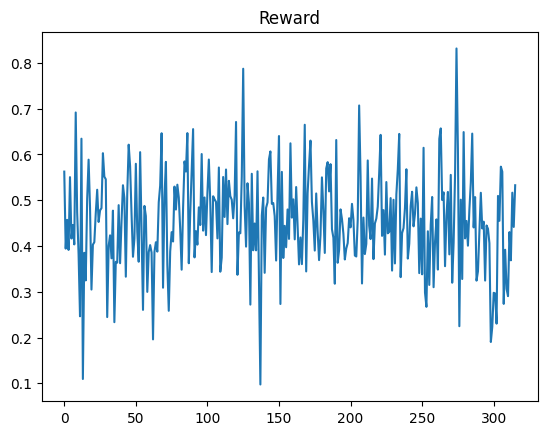

  0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [90]:
for epoch in tqdm(range(2000)):
    
    
    z, info = reward_generator.get_z_from_random_anchors(num_envs, reward_generator.min_num_anchors, reward_generator.max_num_anchors)
    
    trajectory = collect_trajectories(env, z, actor, n_steps=EPISODE_LENGTH, reward_generator=reward_generator)

    for i in range(len(trajectory['states'])):
        buffer.push(
            trajectory['states'][i],
            trajectory['zs'][i],
            trajectory['actions'][i],
            trajectory['rewards'][i],
            trajectory['next_states'][i],
            trajectory['dones'][i],
        )
    
    
    for _ in range(10):
        sac_optimization(
            buffer, 
            actor, q1, q2, q1_target, q2_target,
            actor_optim, q1_optim, q2_optim,
            log_alpha, alpha_optim, target_entropy
        )
    
    
    
    avg_reward = trajectory['rewards'][len(trajectory['rewards'])//num_envs-1::len(trajectory['rewards'])//num_envs].mean()
    rewards_list.append(avg_reward)
    
    
    
    if epoch % 1 == 0:
        clear_output(True)
        plt.plot(rewards_list)
        plt.title('Reward')
        plt.show()

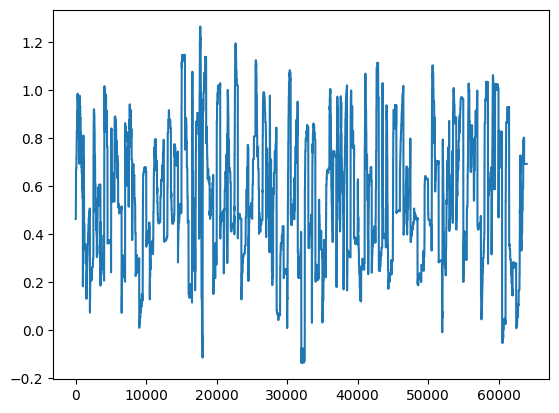

In [ ]:
plt.plot(info['trajectory']['rewards'])

In [ ]:
trajectory, random_states, get_new_states_info = get_new_states(
    5,
    env, model, reward_generator, 
    num_policy_steps=EPISODE_LENGTH, 
    num_random_steps=NUM_RANDOM_STEPS, 
    from_prior=False
)

Get new states:   0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
# torch.save(reward_generator.fre_network.state_dict(), 'models/online_fre_network_3.pth')
# torch.save(model.state_dict(), 'models/online_ppo_model_3.pth')

In [ ]:
# exp_id = 'test'
# os.makedirs(f'figures/exp_{exp_id}', exist_ok=True)
# for i in tqdm(range(len(states_buffer_history))):
#     plt.figure(figsize=(5, 5))
#     plt.scatter(states_buffer_history[i][1][..., 0], states_buffer_history[i][1][..., 1], s=10, c='red')
#     plt.scatter(states_buffer_history[i][0][..., 0], states_buffer_history[i][0][..., 1], s=10, alpha=0.1)
#     plt.scatter(states_buffer_history[i][2][..., 0], states_buffer_history[i][2][..., 1], s=10, alpha=0.1, c='yellow')
#     plt.xlim([-3, 3])
#     plt.ylim([-3, 3])
#     plt.savefig(f"figures/exp_{exp_id}/frame_{i}.png")
#     plt.close()

In [22]:
eval_num_envs = 16
eval_env = TorchWrapper(base_env, num_envs=eval_num_envs)

In [24]:


# eval_z, _ = reward_generator.get_z_from_anchors(anchors, pad_mask)
eval_z, info = reward_generator.get_z_from_random_anchors(eval_num_envs, min_num_anchors=MIN_NUM_ANCHORS, max_num_anchors=MAX_NUM_ANCHORS)
# eval_z, _ = reward_generator.get_z_from_prior(eval_num_envs)

anchors, anchors_rewards = info['anchors'], info['anchors_rewards']

trajectories = []
for _ in tqdm(range(1)):
    trajectories.append(collect_trajectories(eval_env, eval_z, actor, n_steps=EPISODE_LENGTH, reward_generator=reward_generator))

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

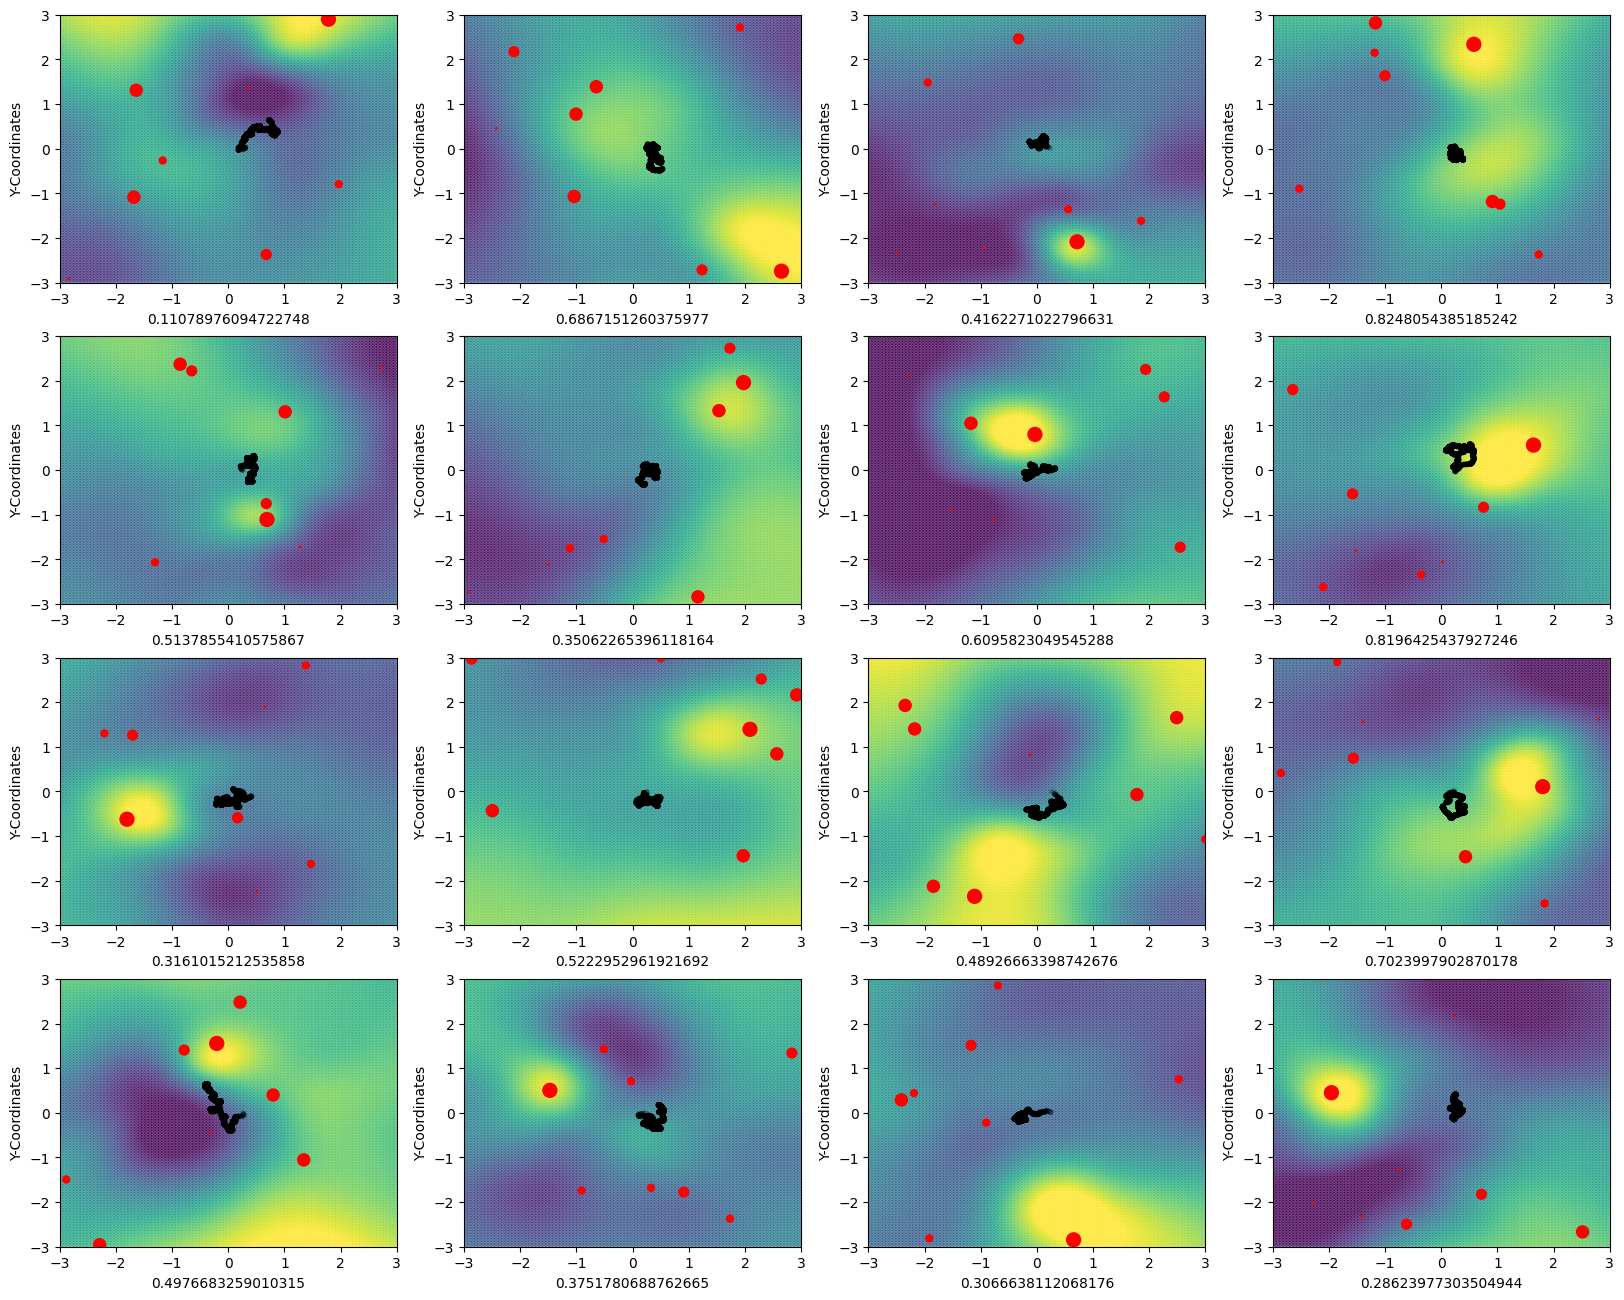

In [26]:
s = 100
# x1_vals = np.linspace(-0.25, 0.25, s) * STATE_SCALE
# x2_vals = np.linspace(-0.175, 0.175, s) * STATE_SCALE

x1_vals = np.linspace(-0.3, 0.3, s) * STATE_SCALE
x2_vals = np.linspace(-0.3, 0.3, s) * STATE_SCALE

# x1_vals = np.linspace(-0.3, 0.3, s)
# x1_vals = np.round((x1_vals + 0.3) / 0.6 * 32)
# x2_vals = np.linspace(-0.3, 0.3, s)
# x2_vals = np.round((x2_vals + 0.3) / 0.6 * 32)



X1, X2 = np.meshgrid(x1_vals, x2_vals)
state_x12 = np.column_stack((X1.ravel(), X2.ravel()))
# print(X1.shape, X2.shape)

state = torch.zeros((s*s, 4), dtype=torch.float32)
state[:, :2] = torch.tensor(state_x12)
state[:, 2:] = torch.rand((s*s, 2)) * 0.1 - 0.05
state = state.to(device)

coods = reward_generator.new_states_buffer.reshape(-1, 2).to(device)

fig, axs = plt.subplots(4, 4, figsize=(20, 16))
axs = axs.flatten()

for i in tqdm(range(len(eval_z))):
    zi = eval_z[i].unsqueeze(0).repeat(state.shape[0], 1)
    with torch.no_grad():
        r = reward_generator.get_reward(state[..., :2], zi).cpu()
    
    
    # axs[i].scatter(state[:, 0].cpu(), state[:, 1].cpu(), c=r, alpha=0.3, s=20)
    # axs[i].scatter(coods[:, 0].cpu(), coods[:, 1].cpu(), c='red', alpha=0.3, s=20)
    axs[i].pcolormesh(X1, X2, r.reshape(X1.shape), cmap='viridis', shading='gouraud', alpha=0.5, vmin=0, vmax=1)
    # axs[i].scatter(anchors[i, :, 0].cpu(), anchors[i, :, 1].cpu(), c='brown', marker='X')
    axs[i].scatter(anchors[i, :, 0].cpu(), anchors[i, :, 1].cpu(), c='red', s=anchors_rewards[i, :, 0].reshape(-1).cpu()*100)
    
    
    for j in range(len(trajectories)):
        trajectory = trajectories[j]
        coords = trajectory['states'][EPISODE_LENGTH*i:EPISODE_LENGTH*(i+1), :2]
        r = trajectory['rewards'][EPISODE_LENGTH*i:EPISODE_LENGTH*(i+1)][-10:].mean()
        axs[i].scatter(coords[:, 0], coords[:, 1], alpha=np.linspace(0.0, 1, len(coords)), s=10, c='black')
        # axs[i].scatter(
        #     reward_generator.new_states_buffer.reshape(-1, 2)[:, 0], 
        #     reward_generator.new_states_buffer.reshape(-1, 2)[:, 1],
        #     s=5, c='red'
        # )
        axs[i].set_xlabel("X-Coordinates")  # Change this to your appropriate label
        axs[i].set_xlabel(f"{r}")
        axs[i].set_ylabel("Y-Coordinates")
        # axs[i].set_xlim([-0.1, 0.1])
        # axs[i].set_xlim([-0.1, 0.1])
    # add_largest_maze_walls(axs[i])

plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

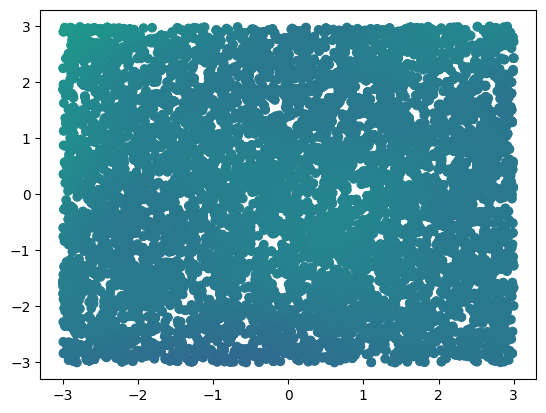

In [ ]:
# num_anchors = 1
# min_num_anchors, max_num_anchors = num_anchors, num_anchors
min_num_anchors, max_num_anchors = 8, 8

(_, _, _), (all_states, _) = reward_generator.get_training_data(
    batch_size=1, 
    min_num_anchors=min_num_anchors, 
    max_num_anchors=max_num_anchors,
    num_states=10000
)
all_states = all_states.to(device)


r = []
for _  in tqdm(range(1000)):
    
    (anchors, anchors_rewards, _), (_, _) = reward_generator.get_training_data(
        batch_size=1, 
        min_num_anchors=min_num_anchors, 
        max_num_anchors=max_num_anchors,
        num_states=10000
    )
    
    anchors = anchors.to(device)
    anchors_rewards = anchors_rewards.to(device)

    with torch.no_grad():
        w_mean, w_log_std = reward_generator.fre_network.get_transformer_encoding(anchors, anchors_rewards, None)   
        w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
        rewards_pred = reward_generator.fre_network.get_reward_pred(w, all_states)
    
    r.append(rewards_pred.flatten().cpu())
    
avg_reward = torch.stack(r).mean(dim=0)
plt.scatter(all_states[0, :, 0].cpu(), all_states[0, :, 1].cpu(), c=avg_reward.detach().cpu(), vmin=0, vmax=1)